In [15]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
print(f"Keras backend: {keras.backend.backend()}") # 이 부분이 'torch'로 나와야 합니다.

Keras backend: torch


In [16]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, \
    LSTM, GRU, BatchNormalization, Flatten, Rescaling, RandomZoom, RandomRotation, RandomFlip
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error
from keras.utils import to_categorical, image_dataset_from_directory
import matplotlib.pyplot as plt
import os, shutil, pathlib, gdown
old_dir = pathlib.Path('./dogs-vs-cats/train')
new_dir = pathlib.Path('cat-dog-dataset20250820')

In [18]:
train = image_dataset_from_directory(new_dir/'train',batch_size=128, image_size=(180,180))
test = image_dataset_from_directory(new_dir/'test',batch_size=128, image_size=(180,180))
val = image_dataset_from_directory(new_dir/'val',batch_size=128, image_size=(180,180))

Found 8000 files belonging to 2 classes.
Found 6000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.


In [6]:
es = EarlyStopping(patience=7, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_6.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomZoom(0.2))
m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 983ms/step - acc: 0.5340 - loss: 1.3050 - val_acc: 0.5000 - val_loss: 0.7702
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 951ms/step - acc: 0.5851 - loss: 0.6766 - val_acc: 0.5000 - val_loss: 0.8942
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - acc: 0.6305 - loss: 0.6362 - val_acc: 0.5235 - val_loss: 0.6917
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 942ms/step - acc: 0.6730 - loss: 0.6032 - val_acc: 0.5000 - val_loss: 1.1242
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 997ms/step - acc: 0.6976 - loss: 0.5840 - val_acc: 0.5008 - val_loss: 0.7339
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 962ms/step - acc: 0.7168 - loss: 0.5538 - val_acc: 0.5000 - val_loss: 0.9752
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 987ms/step - acc: 0.7370 - loss: 0.5324 - val_acc: 0.5347 - val_loss: 0.8463
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 937ms/step - acc: 0.7426 - loss: 0.5184 - val_acc: 0.6685 - val_loss: 0.6523
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 

In [7]:
m.evaluate(test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - acc: 0.9245 - loss: 0.1920


[0.19204607605934143, 0.9244999885559082]

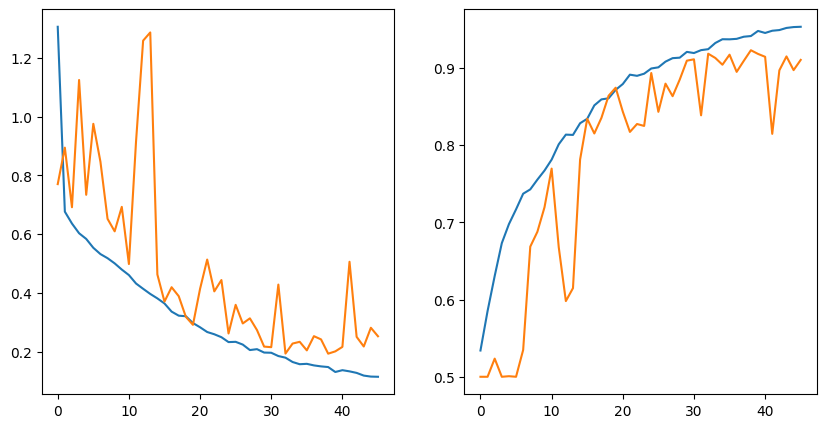

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [4]:
es = EarlyStopping(patience=7, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_7.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomZoom(0.2))
m.add(RandomRotation(0.1))
m.add(RandomFlip('horizontal'))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 951ms/step - acc: 0.5449 - loss: 1.3784 - val_acc: 0.5002 - val_loss: 1.3030
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - acc: 0.5993 - loss: 0.7491 - val_acc: 0.5000 - val_loss: 0.7558
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - acc: 0.6233 - loss: 0.6701 - val_acc: 0.4997 - val_loss: 0.8212
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - acc: 0.6654 - loss: 0.6251 - val_acc: 0.5000 - val_loss: 0.7672
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - acc: 0.7074 - loss: 0.5888 - val_acc: 0.5010 - val_loss: 0.7466
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - acc: 0.7230 - loss: 0.5529 - val_acc: 0.5895 - val_loss: 0.6955
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - acc: 0.7333 - loss: 0.5387 - val_acc: 0.5732 - val_loss: 0.6965
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - acc: 0.7508 - loss: 0.5105 - val_acc: 0.5520 - val_loss: 1.2336
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - acc: 0.7

In [5]:
m.evaluate(test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - acc: 0.9335 - loss: 0.1635


[0.16346487402915955, 0.9334999918937683]

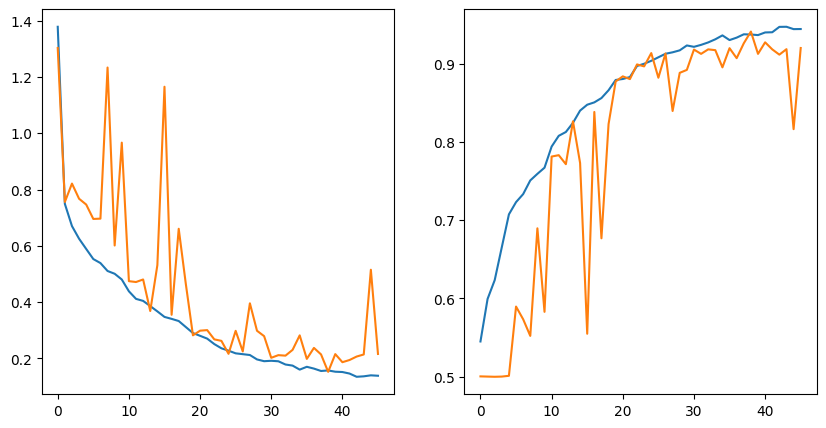

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [8]:
es = EarlyStopping(patience=7, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_8.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomZoom(0.2))
m.add(RandomRotation(0.1))
m.add(RandomFlip('horizontal'))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(BatchNormalization())
m.add(Dropout(0.3))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 851ms/step - acc: 0.5552 - loss: 0.9080 - val_acc: 0.5000 - val_loss: 0.7274
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 870ms/step - acc: 0.6093 - loss: 0.7642 - val_acc: 0.5000 - val_loss: 1.1603
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 863ms/step - acc: 0.6500 - loss: 0.6550 - val_acc: 0.5017 - val_loss: 0.6926
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 863ms/step - acc: 0.6780 - loss: 0.6103 - val_acc: 0.5075 - val_loss: 0.7172
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 913ms/step - acc: 0.6950 - loss: 0.5857 - val_acc: 0.4915 - val_loss: 0.8645
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - acc: 0.7185 - loss: 0.5561 - val_acc: 0.5017 - val_loss: 0.9092
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - acc: 0.7295 - loss: 0.5282 - val_acc: 0.5190 - val_loss: 1.0898
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 954ms/step - acc: 0.7461 - loss: 0.5067 - val_acc: 0.5955 - val_loss: 0.7426
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/

In [9]:
m.evaluate(test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - acc: 0.9592 - loss: 0.1133


[0.11331848800182343, 0.9591666460037231]

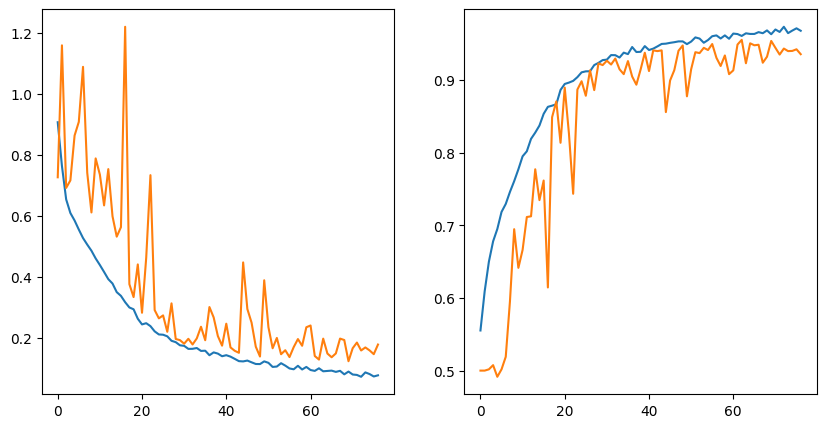

In [10]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

현재 4번 모델이 92.7까지 나옴
7번은 92.73검증, 93.3테스트
8번은 95.40 95.9

In [12]:
from keras.models import load_model

In [19]:
m = load_model('20250820_level_test_8.keras')
tr_scs = m.evaluate(train)
val_scs = m.evaluate(val)
tt_scs = m.evaluate(test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - acc: 0.9883 - loss: 0.0351
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - acc: 0.9540 - loss: 0.1241
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - acc: 0.9592 - loss: 0.1133


In [20]:
all_acc = np.abs(tr_scs[1]-val_scs[1]) + np.abs(tr_scs[1]-tt_scs[1]) + np.abs(tt_scs[1]-val_scs[1])
all_acc # 일반화 오차의 총합 (accuracy관점)

np.float64(0.06850004196166992)

In [21]:
all_loss = np.abs(tr_scs[0]-val_scs[0]) + np.abs(tr_scs[0]-tt_scs[0]) + np.abs(tt_scs[0]-val_scs[0])
all_loss

np.float64(0.1781524047255516)

## 데이터셋 구성 및 모델 구성
- 노트북을 이용하여 학습을 진행하였으며 케라스를 이용하나 엔진은 파이토치로 설정하여 작업을 진행했습니다.(최상단 코드 참고)
- 가급적 정확도를 우선시하여 학습을 진행했습니다.
- 또한 데이터셋을 최대한 크게 잡아 학습을 진행해보고 다소 학습에 시간이 걸려 최종적으로 4000, 2000, 3000의 개수를 구성하여 학습 및 평가, 테스트를 진행했습니다.
    - 데이터셋을 크게(5000,2000, 5000) 잡아서 하였으나 시간이 오래걸림에 따라 더 줄여서 학습하는 것으로 수정하였습니다.
- 옵티마이저의 종류를 주로 3가지 RMSprop, Adam, AdamW 를 적용하여 학습해보았습니다.
    - 초반은 기본 설정의 옵티마이저를 사용하였으나 빠른 과적합을 보였고 주변에서 Adam을 사용한다는 트렌드에 따라 Adam이 무난하다고 판단후 적용하였습니다.
    - 그러나 진행에 따라 다소 결과에 불만족을 느끼게 되어 성능의 일반화를 고려하여 중간부터 AdamW로 테스트하였습니다.
    - AdamW는 성능이 RMSprop에 비해 다소 높은 성능을 보이긴 했으나 설정의 문제였는지 모델의 이론과 달리 초반 학습이 안정적이지 않고 중간부터 큰 폭으로 성능이 올라가는 것을 확인하였습니다.
    - 이에 따라 Rescaling만 적용한 상태에서는 큰 성능을 얻어낼 수 있었으나 학습이 뎌디고 Adam과 달리 문제가 있는 것으로 느껴져 다시 Adam으로 이동하여 학습을 진행했습니다.
    - 해당 Adam 최적화를 통해 타 최적화 기술에 비해 다소 안정적으로 학습을 진행하고 결과를 얻어내었습니다.
- 모델은 점차적 깊게 Conv 연산을 하여 성능을 높일 수 있도록 했습니다.
    - 초반엔 한번씩의 Conv 연산을 진행하여 128까지의 유닛을 설정하였으나 학습의 한계점(정확도 및 손실값이 고정되는 현상)을 보이고 있어 점차 층을 늘리게 되었습니다.
    - 배치정규화와 드롭아웃, 맥스풀링을 계속 조정하면서 95%의 성능이 나올 수 있도록 지속적인 테스트를 거치게 되었습니다.
        - 경험에 따라 겪은 것으로는 맥스풀링이 1차적으로 진행되고 배치정규화를 진행, 이후 드롭아웃을 진행하면 이외의 패턴으로 학습하는 것보다 더 안정적인 학습과 높은 정확도를 보였습니다.
- 배치사이즈는 기존에 32 이후 점차 늘려 128까지 늘려서 작업했습니다.
    - 배치정규화에는 더 많은 데이터가 들어와야 정규화에서의 편향성이 많이 줄어들 것으로 판단하여 노트북에서 돌릴 수 있는 2의 거듭제곱 단위 중 가장 크게 적용할 수 있게 설정하였습니다.
    - 그러나 데이터가 많아질수록 테스트를 하는 데에 시간이 걸리고 성능의 한계와 시간의 적정 분배가 필요하여 128까지 설정하는 것으로 타협했습니다.
    

## 결과
- 학습, 검증, 테스트 점수 (98.8, 95.4, 95.9) 로 평균 95%이상의 정확도를 달성하였습니다.
- 일반화 성능으로 정확도, 손실 (6.85, 17.81) 로 일반화 성능 면에서 꽤 좋다고 생각이 되긴 하지만 정확도가 안정적이지 않은 점은 어떤 부분에서 이렇게 나오는 것인지 확인이 더 필요할 것 같습니다. 또한 일반화 손실이 꽤 큰 것으로 느껴지는데 해당 부분에 대해서는 어떤 모델을 구성하여 돌리거나 최적화, 손실, 데이터셋 구성, 모델 구성 등의 조합을 아무리 바꿔도 계속 변화하는 정도가 컸는데 그나마 최적화 함수인 Adam이 loss를 안정적으로 잡아주는 것을 학습에 loss의 변동이 심한 것은 해결하기 어려웠습니다.